Here we will create our baseline linear model. It will not contain time-dependent exogenous variables. What is more we will not focus on econometrics - BLUE assumptions!

### Dependencies loading

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import (
    mutual_info_classif,
    f_classif,
    SelectFromModel
)  # 
from sklearn.inspection import permutation_importance
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    GridSearchCV,
    TimeSeriesSplit,
)
from sklearn.metrics import (
    mean_squared_error,
    root_mean_squared_error,
    make_scorer,
)
import pickle
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    AdaBoostRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor

%matplotlib inline
plt.style.use("ggplot")

# np.random.seed(1916) #uncomment if you want your code to be reproducible; for the purposes of our activity, let's add some randomness to the results

### Data loading

In [3]:
import os
os.getcwd()

'd:\\finance quantitative\\ML2\\ML2_GBX_extra_points_assignment'

In [5]:
preprocessed_output_data_path = "data"

df = pd.read_csv(f"{preprocessed_output_data_path}/train_fe.csv", index_col=0)
df_test = pd.read_csv(f"{preprocessed_output_data_path}/test_fe.csv", index_col=0)
feature_ranking = pd.read_excel(f"{preprocessed_output_data_path}/feature_ranking.xlsx", index_col=0)
feature_ranking

,mi_score,sign_fscore,sign_fscore_0_1,corr,EN_coef,boruta_rank
rok,0.032073,1.179353e-01,0,-0.032669,0.000000e+00,19
ta,0.582922,1.464884e-03,1,0.267340,-1.404307e-07,49
txt,0.633067,5.246456e-13,1,0.368732,1.466269e-05,1
pi,0.608157,8.614688e-12,1,0.299593,8.453656e-06,3
str,0.293955,1.578384e-46,1,0.372870,NaN,9
...,...,...,...,...,...,...
lev_past,0.511057,2.069335e-01,0,-0.028047,NaN,10
intan_past,0.553899,3.954722e-07,1,0.191545,NaN,51
ppe_past,0.522035,8.060386e-13,1,-0.163085,NaN,40
sale_past,0.521008,3.296618e-01,0,0.039224,NaN,43


**Models to Implement:**

1. **AdaBoost** ([AdaBoostRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.AdaBoostRegressor.html)) - Adaptive Boosting, the pioneering boosting algorithm
2. **GBM** ([GradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingRegressor.html)) - Classic Gradient Boosting Machine from scikit-learn
3. **GBM Histogram** ([HistGradientBoostingRegressor](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.HistGradientBoostingRegressor.html)) - Histogram-based Gradient Boosting (faster, inspired by LightGBM)
4. **XGBoost** ([XGBRegressor](https://xgboost.readthedocs.io/en/stable/python/python_api.html#xgboost.XGBRegressor)) - Extreme Gradient Boosting, industry standard
5. **LightGBM** ([LGBMRegressor](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html)) - Light Gradient Boosting Machine, optimized for speed and memory
6. **CatBoost** ([CatBoostRegressor](https://catboost.ai/en/docs/concepts/python-reference_catboostregressor)) - Categorical Boosting, handles categorical features natively
7. **XGBoostLSS** ([XGBoostLSS](https://github.com/StatMixedML/XGBoostLSS)) - XGBoost for Location, Scale and Shape, probabilistic predictions

# 1. AdaBoost
Try from 20-110 for every 10 features, selcect how many features can be the optimal， feature selection based on boruta_rank, boruta_rank is tree-based feature importance ranking.

In [6]:
x_col = df.columns.drop(["etr","Ticker","Nazwa2"])
for i in np.arange(20, len(x_col)+1, 10):
    print(f"Top {i} features:", feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist())

Top 20 features: ['etr_y_past', 'WB_GDPpc', 'txt', 'diff', 'etr_y_ma', 'diff_ma', 'dlc_cat_(176.129, 200.9]', 'pi', 'txt_cat_(-63.011, -34.811]', 'txt_cat_(308.55, 327.531]', 'pi_cat_(7875.5, 8108.5]', 'roa_past', 'ni', 'str', 'lev_past', 'txt_cat_(24.415, 25.05]', 'sale', 'xrd', 'diff_dta', 'lev_ma']
Top 30 features: ['etr_y_past', 'WB_GDPpc', 'txt', 'diff', 'etr_y_ma', 'diff_ma', 'dlc_cat_(176.129, 200.9]', 'pi', 'txt_cat_(-63.011, -34.811]', 'txt_cat_(308.55, 327.531]', 'pi_cat_(7875.5, 8108.5]', 'roa_past', 'ni', 'str', 'lev_past', 'txt_cat_(24.415, 25.05]', 'sale', 'xrd', 'diff_dta', 'lev_ma', 'revenue', 'cfc', 'roa_clip', 'rok', 'dlc', 'rr_per_sector', 'roa', 'capex_cat_(5451.0, inf]', 'WB_GDPgrowth', 'ppent']
Top 40 features: ['etr_y_past', 'WB_GDPpc', 'txt', 'diff', 'etr_y_ma', 'diff_ma', 'dlc_cat_(176.129, 200.9]', 'pi', 'txt_cat_(-63.011, -34.811]', 'txt_cat_(308.55, 327.531]', 'pi_cat_(7875.5, 8108.5]', 'roa_past', 'ni', 'str', 'lev_past', 'txt_cat_(24.415, 25.05]', 'sale', 

In [7]:
rmse_scorer = make_scorer(
    lambda y_true, y_pred: mean_squared_error(y_true, y_pred) ** 0.5,
    greater_is_better=False
)

tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
import warnings
warnings.filterwarnings("ignore")
base_regressor = DecisionTreeRegressor(max_depth=1)
adaboost_regressor = AdaBoostRegressor(base_regressor, random_state=42)
parameter_grid = {
    'n_estimators': [10, 50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.5, 1.0, 5.0] 
}

results = dict()

for i in np.arange(20, len(x_col)+1, 10):
    print(f"Training model with top {i} features...")
    clf = GridSearchCV(
        adaboost_regressor,
        parameter_grid,
        cv=tscv,
        n_jobs=-1,
        scoring= rmse_scorer,
    )
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    model = clf.fit(df[selected_features], df["etr"])
    results[i] = {
        "model": model,
        "best_params": clf.best_params_,
        "best_score": clf.best_score_
    }
    
    print(f"Best parameters for top {i} features: {clf.best_params_}")
    print(f"Best cross-validation score for top {i} features: {clf.best_score_}")

### Therefore, we can see that the number of features selected do not impact too much on the model performance. 

In [77]:
Test_rmse = {}
for i in np.arange(20, len(x_col)+1, 10):
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    params = pd.DataFrame.from_dict(results, orient="index").loc[i, "best_params"]
    
    model = AdaBoostRegressor(**params).fit(df[selected_features], df["etr"])
    pred = model.predict(df_test[selected_features])
    
    rmse = mean_squared_error(df_test["etr"], pred) ** 0.5
    Test_rmse[i] = {
        "model": model,
        "rmse": rmse
    }
    print(f"Test RMSE for top {i} features: {rmse}")

Test RMSE for top 20 features: 0.08293118923957274
Test RMSE for top 30 features: 0.08345106100383244
Test RMSE for top 40 features: 0.08341396039298762
Test RMSE for top 50 features: 0.08285692630960974
Test RMSE for top 60 features: 0.08365567974398476
Test RMSE for top 70 features: 0.08254727593015922
Test RMSE for top 80 features: 0.08317294401148763
Test RMSE for top 90 features: 0.08365524430855183
Test RMSE for top 100 features: 0.08326271461644119
Test RMSE for top 110 features: 0.08361352082625022


In [93]:
# save the optimal model with 70 features
selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(70).index.tolist()
params = pd.DataFrame.from_dict(results, orient="index").loc[70, "best_params"]
optimal_ada_model = AdaBoostRegressor(**params).fit(df[selected_features], df["etr"])
# save the optiamal_ada_model
with open("models/adaboost_optimal_model.pkl", "wb") as f:
    pickle.dump(optimal_ada_model, f)


#### For test data, the optimal model is 70 features, the optimal rmse is 0.0825

## Feature importance analysis

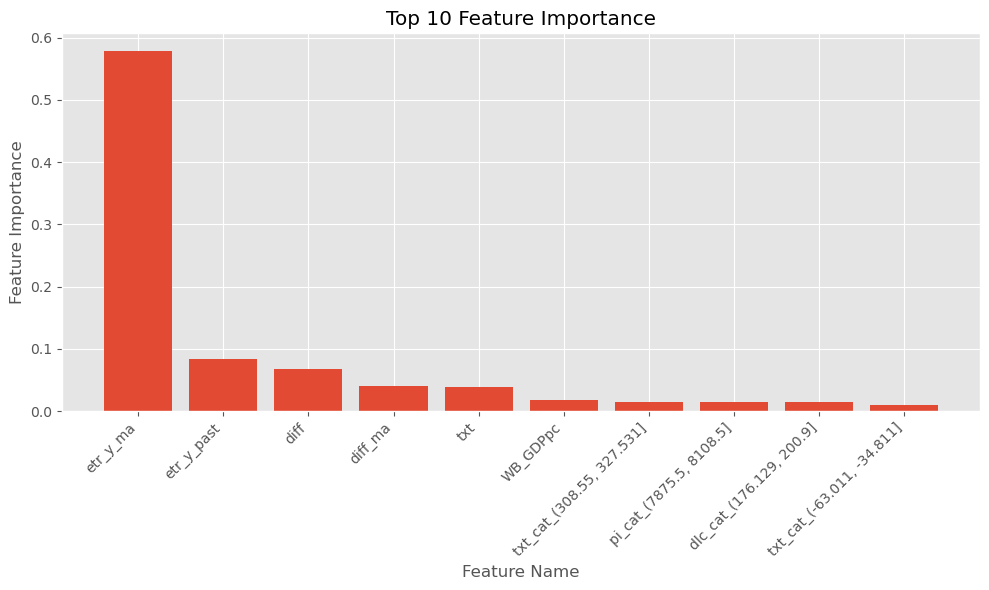

In [94]:
# Feature importance from your trained model
feature_importance = optimal_ada_model.feature_importances_

# Create a DataFrame to combine feature names and importance
feat_df = pd.DataFrame({
    "feature": selected_features,
    "importance": feature_importance
})

# Sort by importance descending and take top 10
top_feats = feat_df.sort_values(by="importance", ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(top_feats)), top_feats["importance"])
plt.xticks(range(len(top_feats)), top_feats["feature"], rotation=45, ha="right")
plt.xlabel("Feature Name")
plt.ylabel("Feature Importance")
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()


# 2. GBM
Based on previous adaboost, I find still need to try more featurs, selcect how many features can be the optimal， feature selection based on boruta_rank, boruta_rank is tree-based feature importance ranking.

In [ ]:
# try GBM model with 20-50 features based on boruta_rank
n_estimators_values = [50, 100, 200]
learning_rate_values = [0.01, 0.1, 0.2]
subsample_values = [0.6, 0.8, 1.0]
max_features_values = [0.25, 0.5, 1.0]

gbm_regressor = GradientBoostingRegressor(random_state=42)
parameter_grid = { 
    'n_estimators': n_estimators_values,
    'learning_rate': learning_rate_values,
    'subsample': subsample_values,
    'max_features': max_features_values
}
results_gbm = dict()
for i in np.arange(20, len(x_col)+1, 10):
    print(f"Training GBM model with top {i} features...")
    clf = GridSearchCV(
        gbm_regressor,
        parameter_grid,
        cv=tscv,
        n_jobs=-1,
        scoring= rmse_scorer,
    )
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    model = clf.fit(df[selected_features], df["etr"])
    results_gbm[i] = {
        "model": model,
        "best_params": clf.best_params_,
        "best_score": clf.best_score_
    }
    
    print(f"Best parameters for top {i} features: {clf.best_params_}")
    print(f"Best cross-validation score for top {i} features: {clf.best_score_}")

In [85]:
Test_rmse = {}
for i in np.arange(20, len(x_col)+1, 10):
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    params = pd.DataFrame.from_dict(results_gbm, orient="index").loc[i, "best_params"]
    
    model = GradientBoostingRegressor(**params).fit(df[selected_features], df["etr"])
    pred = model.predict(df_test[selected_features])
    
    rmse = mean_squared_error(df_test["etr"], pred) ** 0.5
    Test_rmse[i] = {
        "model": model,
        "rmse": rmse
    }
    print(f"Test RMSE for top {i} features: {rmse}")

Test RMSE for top 20 features: 0.07850437316935938
Test RMSE for top 30 features: 0.0776847530660424
Test RMSE for top 40 features: 0.07769300148361988
Test RMSE for top 50 features: 0.07749591967219882
Test RMSE for top 60 features: 0.07735520854326977
Test RMSE for top 70 features: 0.07771691933062184
Test RMSE for top 80 features: 0.07767864487881121
Test RMSE for top 90 features: 0.07719604986196227
Test RMSE for top 100 features: 0.07760604957165586
Test RMSE for top 110 features: 0.07754310102016282


### GBM model has better performance than adaboost, the optimal model is 90 features, the optimal rmse is 0.07719

In [96]:
# save the optimal model with 90 features
selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(90).index.tolist()
params = pd.DataFrame.from_dict(results, orient="index").loc[90, "best_params"]
optimal_gbm_model =GradientBoostingRegressor(**params).fit(df[selected_features], df["etr"])
# save the optiamal_ada_model
with open("models/gbm_optimal_model.pkl", "wb") as f:
    pickle.dump(optimal_gbm_model, f)


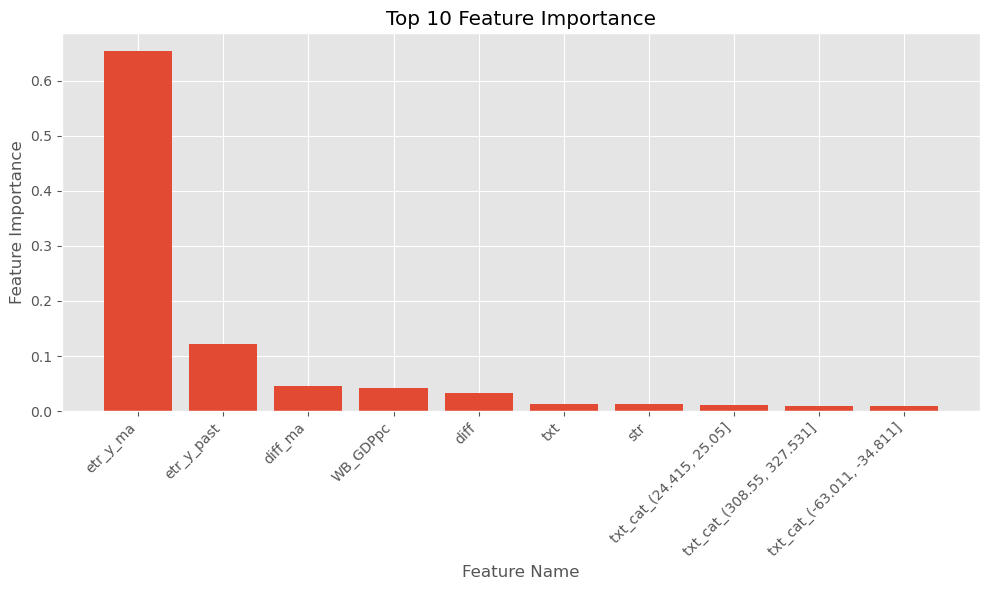

In [97]:
feature_importance = optimal_gbm_model.feature_importances_

feat_df = pd.DataFrame({
    "feature": selected_features,
    "importance": feature_importance
})

# Sort by importance descending and take top 10
top_feats = feat_df.sort_values(by="importance", ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(range(len(top_feats)), top_feats["importance"])
plt.xticks(range(len(top_feats)), top_feats["feature"], rotation=45, ha="right")
plt.xlabel("Feature Name")
plt.ylabel("Feature Importance")
plt.title("Top 10 Feature Importance")
plt.tight_layout()
plt.show()


# 3. GBM Histogram

In [99]:
from sklearn.ensemble import HistGradientBoostingRegressor

param_grid = {
    'max_iter': [50, 100, 200],        # equivalent to n_estimators
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, None],
    'max_bins': [20, 50, 100],
    'min_samples_leaf': [20, 50, 100]
}

results_hist_gbm = dict()

for i in np.arange(20, len(x_col)+1, 10):
    print(f"Training Histogram GBM with top {i} features...")
    
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    
    hgb_regressor = HistGradientBoostingRegressor(random_state=42)
    
    clf = GridSearchCV(
        hgb_regressor,
        param_grid_hist,
        cv=tscv,
        n_jobs=-1,
        scoring=rmse_scorer
    )
    
    model = clf.fit(df[selected_features], df["etr"])
    
    results_hist_gbm[i] = {
        "model": model,
        "best_params": clf.best_params_,
        "best_score": clf.best_score_
    }
    
    print(f"Best parameters for top {i} features: {clf.best_params_}")
    print(f"Best cross-validation score for top {i} features: {clf.best_score_}")


Training Histogram GBM with top 20 features...
Best parameters for top 20 features: {'learning_rate': 0.01, 'max_depth': 5, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 50}
Best cross-validation score for top 20 features: -0.14449369028215062
Training Histogram GBM with top 30 features...
Best parameters for top 30 features: {'learning_rate': 0.01, 'max_depth': 5, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 50}
Best cross-validation score for top 30 features: -0.1437149498640048
Training Histogram GBM with top 40 features...
Best parameters for top 40 features: {'learning_rate': 0.01, 'max_depth': 5, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}
Best cross-validation score for top 40 features: -0.14405351563702104
Training Histogram GBM with top 50 features...
Best parameters for top 50 features: {'learning_rate': 0.01, 'max_depth': 5, 'max_iter': 200, 'max_leaf_nodes': 31, 'min_samples_leaf': 20}
Best cross-validation score for top 50 feat

In [100]:
pd.DataFrame.from_dict(results_hist_gbm, orient="index")

,model,best_params,best_score
20,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': 5, 'max_i...",-0.144494
30,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': 5, 'max_i...",-0.143715
40,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': 5, 'max_i...",-0.144054
50,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': 5, 'max_i...",-0.144207
60,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': None, 'ma...",-0.144029
70,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': None, 'ma...",-0.144104
80,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': None, 'ma...",-0.144074
90,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': 10, 'max_...",-0.144088
100,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': None, 'ma...",-0.144058
110,"GridSearchCV(cv=TimeSeriesSplit(gap=0, max_tra...","{'learning_rate': 0.01, 'max_depth': None, 'ma...",-0.144099


#### For vaildation data, the optimal model is 30 features

In [102]:
Test_rmse = {}
for i in np.arange(20, len(x_col)+1, 10):
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    params = pd.DataFrame.from_dict(results_hist_gbm, orient="index").loc[i, "best_params"]
    
    model = HistGradientBoostingRegressor(**params).fit(df[selected_features], df["etr"])
    pred = model.predict(df_test[selected_features])
    
    rmse = mean_squared_error(df_test["etr"], pred) ** 0.5
    Test_rmse[i] = {
        "model": model,
        "rmse": rmse
    }
    print(f"Test RMSE for top {i} features: {rmse}")

Test RMSE for top 20 features: 0.0786800593526764
Test RMSE for top 30 features: 0.07800004077044477
Test RMSE for top 40 features: 0.0779615531436587
Test RMSE for top 50 features: 0.07807924017020239
Test RMSE for top 60 features: 0.07903499155986136
Test RMSE for top 70 features: 0.07887834527518423
Test RMSE for top 80 features: 0.07885153304434699
Test RMSE for top 90 features: 0.0785614764586267
Test RMSE for top 100 features: 0.07847835008350208
Test RMSE for top 110 features: 0.07840452365090911


### Hist GBM model has similar performance with GBM, the optimal model is 40 features, the optimal rmse is 0.07796

In [104]:
# save the optimal model with 40 features
selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(40).index.tolist()
params = pd.DataFrame.from_dict(results_hist_gbm, orient="index").loc[40, "best_params"]
optimal_hist_gbm_model =HistGradientBoostingRegressor(**params).fit(df[selected_features], df["etr"])
# save the optiamal_ada_model
with open("models/hist_gbm_optimal_model.pkl", "wb") as f:
    pickle.dump(optimal_hist_gbm_model, f)


In [17]:
df.columns.tolist()

['Ticker',
 'Nazwa2',
 'rok',
 'ta',
 'txt',
 'pi',
 'str',
 'xrd',
 'ni',
 'ppent',
 'intant',
 'dlc',
 'dltt',
 'capex',
 'revenue',
 'cce',
 'adv',
 'etr',
 'diff',
 'roa',
 'lev',
 'intan',
 'rd',
 'ppe',
 'sale',
 'cash_holdings',
 'adv_expenditure',
 'capex2',
 'cfc',
 'dta',
 'capex2_scaled',
 'y_v2x_polyarchy',
 'y_e_p_polity',
 'y_BR_Democracy',
 'WB_GDPgrowth',
 'WB_GDPpc',
 'WB_Inflation',
 'rr_per_country',
 'rr_per_sector',
 'sektor_consumer discretionary',
 'sektor_consumer staples',
 'sektor_energy',
 'sektor_health care',
 'sektor_industrials',
 'sektor_materials',
 'sektor_real estate',
 'sektor_technology',
 'sektor_utilities',
 'gielda_2',
 'gielda_3',
 'gielda_4',
 'gielda_5',
 'ta_log',
 'txt_cat_(-63.011, -34.811]',
 'txt_cat_(-34.811, 0.488]',
 'txt_cat_(0.488, 24.415]',
 'txt_cat_(24.415, 25.05]',
 'txt_cat_(25.05, 308.55]',
 'txt_cat_(308.55, 327.531]',
 'txt_cat_(327.531, inf]',
 'pi_cat_(-8975.0, -1.523]',
 'pi_cat_(-1.523, 157.119]',
 'pi_cat_(157.119, 465.9

# 4. XGBM 

In [11]:
import re

# Clean all column names in the DataFrame
df.columns = [re.sub(r'\W+', '_', str(col)).rstrip('_') for col in df.columns]
df.columns = [col.replace('__', '_') for col in df.columns]

df_test.columns = [re.sub(r'\W+', '_', str(col)).rstrip('_') for col in df_test.columns]
df_test.columns = [col.replace('__', '_') for col in df_test.columns]

x_col = df.columns.drop(["etr","Ticker","Nazwa2"])

In [12]:
feature_ranking.index = [re.sub(r'\W+', '_', str(col)).rstrip('_') for col in feature_ranking.index]
feature_ranking.index = [col.replace('__', '_') for col in feature_ranking.index]
feature_ranking.index.tolist()

['rok',
 'ta',
 'txt',
 'pi',
 'str',
 'xrd',
 'ni',
 'ppent',
 'intant',
 'dlc',
 'dltt',
 'capex',
 'revenue',
 'cce',
 'adv',
 'diff',
 'roa',
 'lev',
 'intan',
 'rd',
 'ppe',
 'sale',
 'cash_holdings',
 'adv_expenditure',
 'capex2',
 'cfc',
 'dta',
 'capex2_scaled',
 'y_v2x_polyarchy',
 'y_e_p_polity',
 'y_BR_Democracy',
 'WB_GDPgrowth',
 'WB_GDPpc',
 'WB_Inflation',
 'rr_per_country',
 'rr_per_sector',
 'sektor_consumer_discretionary',
 'sektor_consumer_staples',
 'sektor_energy',
 'sektor_health_care',
 'sektor_industrials',
 'sektor_materials',
 'sektor_real_estate',
 'sektor_technology',
 'sektor_utilities',
 'gielda_2',
 'gielda_3',
 'gielda_4',
 'gielda_5',
 'ta_log',
 'txt_cat_63_011_34_811',
 'txt_cat_34_811_0_488',
 'txt_cat_0_488_24_415',
 'txt_cat_24_415_25_05',
 'txt_cat_25_05_308_55',
 'txt_cat_308_55_327_531',
 'txt_cat_327_531_inf',
 'pi_cat_8975_0_1_523',
 'pi_cat_1_523_157_119',
 'pi_cat_157_119_465_9',
 'pi_cat_465_9_7875_5',
 'pi_cat_7875_5_8108_5',
 'pi_cat_8108

In [ ]:
param_grid = {
    "learning_rate": [0.01, 0.1, 0.2, 0.3, 0.5],
    "max_depth": [3, 4, 5, 6, 7, 8, 9, 10],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "min_child_weight": [1, 2, 3, 4, 5],
    "n_estimators": [10, 50, 100]
}
xgb_regressor = xgb.XGBRegressor(objective='reg:squarederror', random_state=42)
results_xgb = dict()

import re

for i in np.arange(20, len(x_col)+1, 10):
    print(f"Training Histogram GBM with top {i} features...")

    # select top i features
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()

    clf = RandomizedSearchCV(
        xgb_regressor,
        param_distributions=param_grid,
        scoring=rmse_scorer,
        cv=tscv,
        n_jobs=-1
    )

    model = clf.fit(df[selected_features], df["etr"])

    results_xgb[i] = {
        "model": model,
        "best_params": clf.best_params_,
        "best_score": clf.best_score_
    }

    print(f"Best parameters for top {i} features: {clf.best_params_}")
    print(f"Best cross-validation score for top {i} features: {clf.best_score_}")

Training Histogram GBM with top 20 features...
Best parameters for top 20 features: {'subsample': 0.7, 'n_estimators': 50, 'min_child_weight': 2, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best cross-validation score for top 20 features: -0.1497439907585944
Training Histogram GBM with top 30 features...
Best parameters for top 20 features: {'subsample': 0.7, 'n_estimators': 50, 'min_child_weight': 2, 'max_depth': 9, 'learning_rate': 0.01, 'colsample_bytree': 1.0}
Best cross-validation score for top 20 features: -0.1497439907585944
Training Histogram GBM with top 30 features...
Best parameters for top 30 features: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best cross-validation score for top 30 features: -0.14672396011962188
Training Histogram GBM with top 40 features...
Best parameters for top 30 features: {'subsample': 0.9, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 6

In [48]:
pd.DataFrame.from_dict(results_xgb, orient="index")

,model,best_params,best_score
20,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",-0.149744
30,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 0.9, 'n_estimators': 100, 'min_c...",-0.146724
40,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 1.0, 'n_estimators': 100, 'min_c...",-0.148609
50,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 0.7, 'n_estimators': 100, 'min_c...",-0.149741
60,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 1.0, 'n_estimators': 100, 'min_c...",-0.147177
70,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 0.8, 'n_estimators': 100, 'min_c...",-0.147523
80,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 0.7, 'n_estimators': 100, 'min_c...",-0.147368
90,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 1.0, 'n_estimators': 10, 'min_ch...",-0.148774
100,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 0.7, 'n_estimators': 10, 'min_ch...",-0.152225
110,"RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, m...","{'subsample': 0.7, 'n_estimators': 100, 'min_c...",-0.147482


In [49]:
Test_rmse = {}
for i in np.arange(20, len(x_col)+1, 10):
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    params = pd.DataFrame.from_dict(results_xgb, orient="index").loc[i, "best_params"]
    
    model = xgb.XGBRegressor(**params).fit(df[selected_features], df["etr"])
    pred = model.predict(df_test[selected_features])
    
    rmse = mean_squared_error(df_test["etr"], pred) ** 0.5
    Test_rmse[i] = {
        "model": model,
        "rmse": rmse
    }
    print(f"Test RMSE for top {i} features: {rmse}")

Test RMSE for top 20 features: 0.07913625139036451
Test RMSE for top 30 features: 0.07616278343426895
Test RMSE for top 40 features: 0.07826067737320141
Test RMSE for top 50 features: 0.0833473825894071
Test RMSE for top 40 features: 0.07826067737320141
Test RMSE for top 50 features: 0.0833473825894071
Test RMSE for top 60 features: 0.07749613978819592
Test RMSE for top 60 features: 0.07749613978819592
Test RMSE for top 70 features: 0.07652948562029571
Test RMSE for top 70 features: 0.07652948562029571
Test RMSE for top 80 features: 0.0776212371624959
Test RMSE for top 80 features: 0.0776212371624959
Test RMSE for top 90 features: 0.0824343110127696
Test RMSE for top 100 features: 0.0851711326244716
Test RMSE for top 90 features: 0.0824343110127696
Test RMSE for top 100 features: 0.0851711326244716
Test RMSE for top 110 features: 0.07559867532084177
Test RMSE for top 110 features: 0.07559867532084177


### XGB model has the best performance so far, the optimal model is 110 features, the optimal rmse is 0.07559

In [52]:
# save the optimal model with 110 features
selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(110).index.tolist()
params = pd.DataFrame.from_dict(results_xgb, orient="index").loc[110, "best_params"]
optimal_xgbm_model =xgb.XGBRegressor(**params).fit(df[selected_features], df["etr"])
# save the optiamal_ada_model
with open("models/xgbm_optimal_model.pkl", "wb") as f:
    pickle.dump(optimal_xgbm_model, f)

# LightGBM ([LGBMRegressor]

In [59]:

from lightgbm import LGBMRegressor

# Base parameters
base_params = {
    'boosting_type': 'gbdt',
    'objective': 'regression',
    'random_state': 42
}

# Define a parameter grid for tuning
param_grid_lgb = {
    'num_leaves': [31, 50],
    'learning_rate': [0.01, 0.05],
    'n_estimators': [50, 100],
    'feature_fraction': [0.8, 0.9],
    'bagging_fraction': [ 0.8, 0.9]
}

results_lgb = dict()

for i in np.arange(20, len(x_col)+1, 10):
    print(f"Training LightGBM with top {i} features...")

    # select top i features
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()


    lgb_regressor = LGBMRegressor(**base_params)

    clf = GridSearchCV(
        estimator=lgb_regressor,
        param_grid=param_grid_lgb,
        cv=tscv,
        n_jobs=-1,
        scoring=rmse_scorer
    )

    model = clf.fit(df[selected_features], df["etr"])

    results_lgb[i] = {
        "model": model,
        "best_params": clf.best_params_,
        "best_score": clf.best_score_
    }

    print(f"Best parameters for top {i} features: {clf.best_params_}")
    print(f"Best cross-validation score for top {i} features: {clf.best_score_}")


Training LightGBM with top 20 features...
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001160 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3530
[LightGBM] [Info] Number of data points in the train set: 3993, number of used features: 18
[LightGBM] [Info] Start training from score 0.215034
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] 

In [ ]:
Test_rmse = {}
for i in np.arange(20, len(x_col)+1, 10):
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    params = pd.DataFrame.from_dict(results_lgb, orient="index").loc[i, "best_params"]
    
    model = LGBMRegressor(**params).fit(df[selected_features], df["etr"])
    pred = model.predict(df_test[selected_features])
    
    rmse = mean_squared_error(df_test["etr"], pred) ** 0.5
    Test_rmse[i] = {
        "model": model,
        "rmse": rmse
    }
    print(f"Test RMSE for top {i} features: {rmse}")

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001143 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3530
[LightGBM] [Info] Number of data points in the train set: 3993, number of used features: 18
[LightGBM] [Info] Start training from score 0.215034
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, sub

In [62]:
pd.DataFrame.from_dict(Test_rmse, orient="index")

,model,rmse
20,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.079950
30,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.080973
40,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.079761
50,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.078176
60,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.078055
70,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.078703
80,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.077467
90,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.078100
100,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.076853
110,"LGBMRegressor(bagging_fraction=0.8, feature_fr...",0.078337


### Best Lgbm is 100 features, with rmse 0.076

In [64]:
# save the optimal model with 110 features
selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(100).index.tolist()
params = pd.DataFrame.from_dict(results_xgb, orient="index").loc[100, "best_params"]
optimal_lgbm_model =LGBMRegressor(**params).fit(df[selected_features], df["etr"])
# save the optiamal_ada_model
with open("models/lgbm_optimal_model.pkl", "wb") as f:
    pickle.dump(optimal_lgbm_model, f)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004339 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12669
[LightGBM] [Info] Number of data points in the train set: 3993, number of used features: 98
[LightGBM] [Info] Start training from score 0.215034
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


# CatBoost

In [66]:
from catboost import CatBoostRegressor

# Base parameters for CatBoost
base_params_cb = {
    'loss_function': 'RMSE',   # equivalent to regression objective
    'random_seed': 42,
    'verbose': 0
}

# Define a parameter grid for tuning
param_grid_cb = {
    'depth': [6, 8],               # similar to controlling tree complexity
    'learning_rate': [0.01, 0.05],
    'iterations': [50, 100],       # similar to n_estimators
    'l2_leaf_reg': [3, 5],         # regularization
    'bagging_temperature': [0.8, 0.9]  # similar to bagging_fraction
}

results_cb = dict()

for i in np.arange(20, len(x_col)+1, 10):
    print(f"Training CatBoost with top {i} features...")

    # select top i features
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()

    cb_regressor = CatBoostRegressor(**base_params_cb)

    clf = GridSearchCV(
        estimator=cb_regressor,
        param_grid=param_grid_cb,
        cv=tscv,
        n_jobs=-1,
        scoring=rmse_scorer,
         error_score=np.nan  # prevent sklearn from printing fit errors
    )

    model = clf.fit(df[selected_features], df["etr"])

    results_cb[i] = {
        "model": model,
        "best_params": clf.best_params_,
        "best_score": clf.best_score_
    }

    print(f"Best parameters for top {i} features: {clf.best_params_}")
    print(f"Best cross-validation score for top {i} features: {clf.best_score_}")


Training CatBoost with top 20 features...
Best parameters for top 20 features: {'bagging_temperature': 0.8, 'depth': 6, 'iterations': 50, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Best cross-validation score for top 20 features: -0.14526346484311678
Training CatBoost with top 30 features...
Best parameters for top 20 features: {'bagging_temperature': 0.8, 'depth': 6, 'iterations': 50, 'l2_leaf_reg': 3, 'learning_rate': 0.05}
Best cross-validation score for top 20 features: -0.14526346484311678
Training CatBoost with top 30 features...
Best parameters for top 30 features: {'bagging_temperature': 0.8, 'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Best cross-validation score for top 30 features: -0.1444630339680489
Training CatBoost with top 40 features...
Best parameters for top 30 features: {'bagging_temperature': 0.8, 'depth': 8, 'iterations': 100, 'l2_leaf_reg': 5, 'learning_rate': 0.05}
Best cross-validation score for top 30 features: -0.1444630339680489
Trai

In [67]:
Test_rmse = {}
for i in np.arange(20, len(x_col)+1, 10):
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(i).index.tolist()
    params = pd.DataFrame.from_dict(results_cb, orient="index").loc[i, "best_params"]
    
    model = CatBoostRegressor(**params).fit(df[selected_features], df["etr"])
    pred = model.predict(df_test[selected_features])
    
    rmse = mean_squared_error(df_test["etr"], pred) ** 0.5
    Test_rmse[i] = {
        "model": model,
        "rmse": rmse
    }
    print(f"Test RMSE for top {i} features: {rmse}")

0:	learn: 0.1527354	total: 2.55ms	remaining: 125ms
1:	learn: 0.1516628	total: 5.33ms	remaining: 128ms
2:	learn: 0.1504302	total: 7.66ms	remaining: 120ms
3:	learn: 0.1494660	total: 9.59ms	remaining: 110ms
4:	learn: 0.1486280	total: 11.3ms	remaining: 102ms
5:	learn: 0.1477218	total: 13.6ms	remaining: 99.4ms
6:	learn: 0.1468530	total: 15.6ms	remaining: 95.5ms
7:	learn: 0.1460046	total: 17.2ms	remaining: 90.1ms
8:	learn: 0.1453401	total: 19.2ms	remaining: 87.7ms
9:	learn: 0.1446882	total: 21.6ms	remaining: 86.2ms
10:	learn: 0.1441199	total: 24ms	remaining: 85.1ms
11:	learn: 0.1435625	total: 26.1ms	remaining: 82.7ms
12:	learn: 0.1430200	total: 28.4ms	remaining: 80.9ms
13:	learn: 0.1424963	total: 30.6ms	remaining: 78.8ms
14:	learn: 0.1420448	total: 32.9ms	remaining: 76.8ms
15:	learn: 0.1416443	total: 35.1ms	remaining: 74.6ms
16:	learn: 0.1412569	total: 37.5ms	remaining: 72.9ms
17:	learn: 0.1408164	total: 39.7ms	remaining: 70.5ms
18:	learn: 0.1404392	total: 41.4ms	remaining: 67.6ms
19:	learn:

In [71]:
pd.DataFrame.from_dict(Test_rmse, orient="index")

,model,rmse
20,<catboost.core.CatBoostRegressor object at 0x0...,0.077639
30,<catboost.core.CatBoostRegressor object at 0x0...,0.078525
40,<catboost.core.CatBoostRegressor object at 0x0...,0.077232
50,<catboost.core.CatBoostRegressor object at 0x0...,0.077286
60,<catboost.core.CatBoostRegressor object at 0x0...,0.078024
70,<catboost.core.CatBoostRegressor object at 0x0...,0.077922
80,<catboost.core.CatBoostRegressor object at 0x0...,0.077143
90,<catboost.core.CatBoostRegressor object at 0x0...,0.077131
100,<catboost.core.CatBoostRegressor object at 0x0...,0.077310
110,<catboost.core.CatBoostRegressor object at 0x0...,0.077347


### Therefore, we can see that the optimal number of features is 0.0771 with 90 features

In [72]:
# save the optimal model with 90 features
selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(90).index.tolist()
params = pd.DataFrame.from_dict(results_cb, orient="index").loc[90, "best_params"]
optimal_cat_model =CatBoostRegressor(**params).fit(df[selected_features], df["etr"])
# save the optiamal_ada_model
with open("models/cat_optimal_model.pkl", "wb") as f:
    pickle.dump(optimal_cat_model, f)

0:	learn: 0.1528123	total: 11.8ms	remaining: 1.17s
1:	learn: 0.1515284	total: 22.5ms	remaining: 1.1s
2:	learn: 0.1504821	total: 33.3ms	remaining: 1.07s
3:	learn: 0.1493719	total: 45.1ms	remaining: 1.08s
4:	learn: 0.1482865	total: 55.9ms	remaining: 1.06s
5:	learn: 0.1473637	total: 66.6ms	remaining: 1.04s
6:	learn: 0.1464788	total: 78.5ms	remaining: 1.04s
7:	learn: 0.1456109	total: 90.8ms	remaining: 1.04s
8:	learn: 0.1448263	total: 102ms	remaining: 1.03s
9:	learn: 0.1439892	total: 113ms	remaining: 1.02s
10:	learn: 0.1432530	total: 124ms	remaining: 1s
11:	learn: 0.1425699	total: 136ms	remaining: 995ms
12:	learn: 0.1419579	total: 147ms	remaining: 984ms
13:	learn: 0.1413039	total: 158ms	remaining: 969ms
14:	learn: 0.1406536	total: 169ms	remaining: 955ms
15:	learn: 0.1400975	total: 179ms	remaining: 942ms
16:	learn: 0.1395276	total: 191ms	remaining: 930ms
17:	learn: 0.1389611	total: 203ms	remaining: 923ms
18:	learn: 0.1383979	total: 212ms	remaining: 905ms
19:	learn: 0.1377711	total: 222ms	rem

# XGBoostLSS

In [14]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 4)

class GradientBoostingAnalytical:
    """
    Gradient Boosting implementation with analytical gradient computation.
    Uses MSE loss with explicit gradient: gradient = y - y_hat
    """
    def __init__(self, n_estimators: int = 100, learning_rate: float = 0.1,
                 max_depth: int = 3, min_samples_split: int = 2):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split

        self.estimators = []
        self.init_value = None
        self.is_trained = False

        # Store training history for visualization
        self.train_losses = []

    def _fit_init_value(self, y: np.array):
        """Initialize with mean of target values (optimal for MSE)"""
        self.init_value = np.mean(y)

    def _compute_gradient_analytical(self, y: np.array, y_hat: np.array):
        """
        Compute negative gradient of MSE loss analytically.
        For L(y, F) = 1/2 * (y - F)^2
        dL/dF = -(y - F)
        Negative gradient: -dL/dF = (y - F) = residuals
        """
        return y - y_hat

    def _predict(self, X: np.array):
        """Internal prediction method"""
        output = np.full(len(X), self.init_value)
        for estimator in self.estimators:
            output += self.learning_rate * estimator.predict(X)
        return output

    def predict(self, X: np.array):
        """Make predictions on new data"""
        if not self.is_trained:
            raise Exception("Model is not trained. Call fit() first.")
        return self._predict(X)

    def fit(self, X: np.array, y: np.array, X_val=None, y_val=None):
        """
        Fit the gradient boosting model.

        Parameters:
        -----------
        X : array-like, shape (n_samples, n_features)
            Training data
        y : array-like, shape (n_samples,)
            Target values
        X_val : array-like, optional
            Validation data for tracking loss
        y_val : array-like, optional
            Validation targets
        """
        # Initialize model
        self._fit_init_value(y)
        self.is_trained = True
        self.train_losses = []

        # Boosting iterations
        for m in tqdm(range(self.n_estimators), desc="Training"):
            # Get current predictions
            y_hat = self._predict(X)

            # Compute pseudo-residuals (negative gradient)
            residuals = self._compute_gradient_analytical(y, y_hat)

            # Fit weak learner to residuals
            tree = DecisionTreeRegressor(
                max_depth=self.max_depth,
                min_samples_split=self.min_samples_split,
                random_state=42
            )
            tree.fit(X, residuals)

            # Add tree to ensemble
            self.estimators.append(tree)

            # Track training loss
            y_hat_updated = self._predict(X)
            train_loss = mean_squared_error(y, y_hat_updated)
            self.train_losses.append(train_loss)

        return self

print("GradientBoostingAnalytical class defined successfully!")

GradientBoostingAnalytical class defined successfully!


In [20]:
selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(50).index.tolist()
X = df[selected_features].values
y = df["etr"].values
# split data by time 
split_index = int(0.8 * len(df))
X_train, X_val = X[:split_index], X[split_index:]
y_train, y_val = y[:split_index], y[split_index:]

# df_test
X_test = df_test[selected_features].values
y_test = df_test["etr"].values

In [21]:
# Train the model with analytical gradient
model_analytical = GradientBoostingAnalytical(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3
)

model_analytical.fit(X_train, y_train)

# Make predictions
y_pred_train = model_analytical.predict(X_train)
y_pred_test = model_analytical.predict(X_test)

# Evaluate
train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)
train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

print(f"\n{'='*60}")
print("Gradient Boosting with Analytical Gradient - Results")
print(f"{'='*60}")
print(f"Train MSE: {train_mse:.4f} | Train R²: {train_r2:.4f}")
print(f"Test MSE:  {test_mse:.4f} | Test R²:  {test_r2:.4f}")
print(f"{'='*60}")


Training: 100%|██████████| 100/100 [00:04<00:00, 20.23it/s]


Gradient Boosting with Analytical Gradient - Results
Train MSE: 0.0117 | Train R²: 0.4855
Test MSE:  0.0068 | Test R²:  0.0998


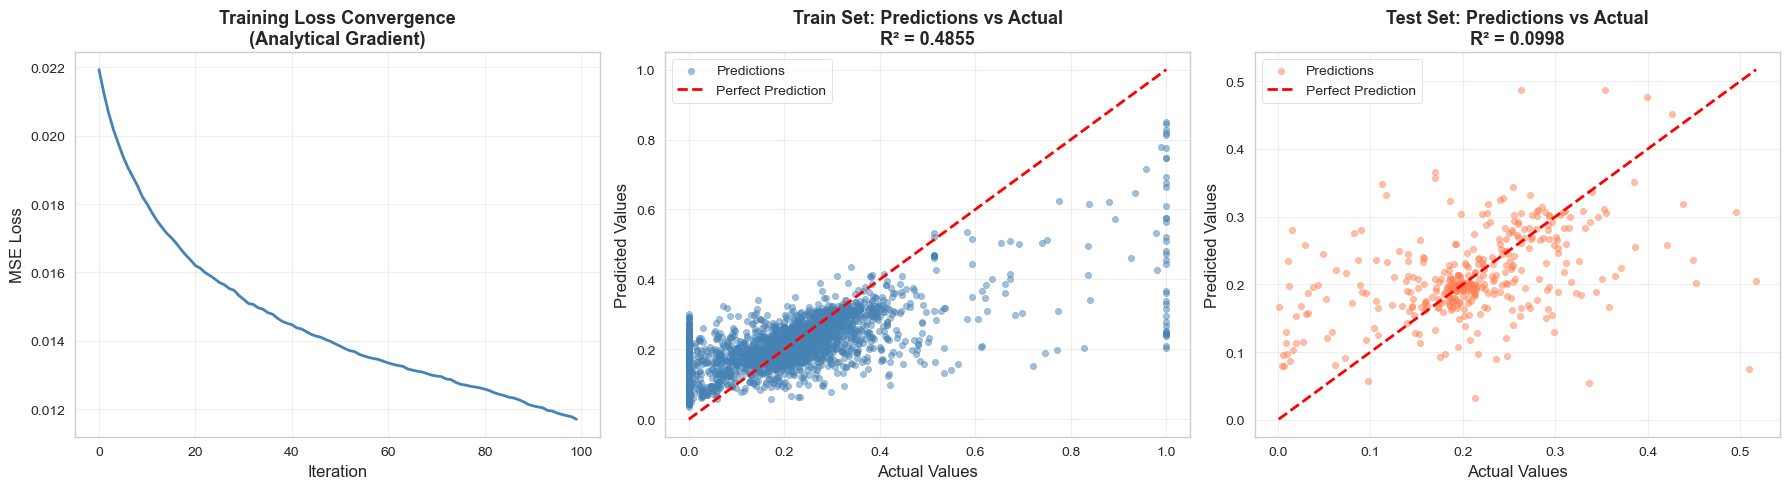

In [22]:
# Visualize results for analytical gradient version
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Training loss over iterations
axes[0].plot(model_analytical.train_losses, linewidth=2, color='steelblue')
axes[0].set_xlabel('Iteration', fontsize=12)
axes[0].set_ylabel('MSE Loss', fontsize=12)
axes[0].set_title('Training Loss Convergence\n(Analytical Gradient)', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Plot 2: Predictions vs Actual (Train)
axes[1].scatter(y_train, y_pred_train, alpha=0.5, s=20, color='steelblue', label='Predictions')
axes[1].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual Values', fontsize=12)
axes[1].set_ylabel('Predicted Values', fontsize=12)
axes[1].set_title(f'Train Set: Predictions vs Actual\nR² = {train_r2:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Plot 3: Predictions vs Actual (Test)
axes[2].scatter(y_test, y_pred_test, alpha=0.5, s=20, color='coral', label='Predictions')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             'r--', lw=2, label='Perfect Prediction')
axes[2].set_xlabel('Actual Values', fontsize=12)
axes[2].set_ylabel('Predicted Values', fontsize=12)
axes[2].set_title(f'Test Set: Predictions vs Actual\nR² = {test_r2:.4f}',
                  fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Save the analytical gradient boosting model
with open("models/gradient_boosting_analytical_model.pkl", "wb") as f:
    pickle.dump(model_analytical, f)

### Finanl step: Compare these models

In [26]:
# load all these models, and compare the rmse
with open("models/adaboost_optimal_model.pkl", "rb") as f:
    adaboost_optimal_model = pickle.load(f)

with open("models/gbm_optimal_model.pkl", "rb") as f:
    gbm_optimal_model = pickle.load(f)

with open("models/hist_gbm_optimal_model.pkl", "rb") as f:
    hist_gbm_optimal_model = pickle.load(f)

with open("models/xgbm_optimal_model.pkl", "rb") as f:
    xgbm_optimal_model = pickle.load(f)

with open("models/lgbm_optimal_model.pkl", "rb") as f:
    lgbm_optimal_model = pickle.load(f)

with open("models/cat_optimal_model.pkl", "rb") as f:
    cat_optimal_model = pickle.load(f)

with open("models/gradient_boosting_analytical_model.pkl", "rb") as f:
    gradient_boosting_analytical_model = pickle.load(f)

print("All models loaded successfully!")

All models loaded successfully!


In [29]:
# Compare RMSE of all models on test dataset

# Dictionary to store model information
models_comparison = {
    'AdaBoost': {
        'model': adaboost_optimal_model,
        'n_features': 70,
    },
    'GBM': {
        'model': gbm_optimal_model,
        'n_features': 90,
    },
    'Hist GBM': {
        'model': hist_gbm_optimal_model,
        'n_features': 40,
    },
    'XGBoost': {
        'model': xgbm_optimal_model,
        'n_features': 110,
    },
    'LightGBM': {
        'model': lgbm_optimal_model,
        'n_features': 100,
    },
    'CatBoost': {
        'model': cat_optimal_model,
        'n_features': 90,
    },
    'XgbLSS':{
        'model': gradient_boosting_analytical_model,
        'n_features': 50,
    }
}


In [31]:
models_comparison

{'AdaBoost': {'model': AdaBoostRegressor(learning_rate=0.01),
  'n_features': 70},
 'GBM': {'model': GradientBoostingRegressor(learning_rate=0.01, n_estimators=50),
  'n_features': 90},
 'Hist GBM': {'model': HistGradientBoostingRegressor(learning_rate=0.01, max_depth=5, max_iter=200),
  'n_features': 40},
 'XGBoost': {'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.7, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               feature_weights=None, gamma=None, grow_policy=None,
               importance_type=None, interaction_constraints=None,
               learning_rate=0.01, max_bin=None, max_cat_threshold=None,
               max_cat_to_onehot=None, max_delta_step=None, max_depth=7,
               max_leaves=None, min_child_weight=2, missing=nan,
               monotone_constraints=None, mult

In [38]:
# get the test rmse for each model
test_rmse_results = {}
for model_name, model_info in models_comparison.items():
    n_features = model_info['n_features']
    selected_features = feature_ranking.sort_values(by="boruta_rank", ascending=True).head(n_features).index.tolist()
    X_test = df_test[selected_features].values
    y_test = df_test["etr"].values
    
    model = model_info['model']
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred) ** 0.5
    test_rmse_results[model_name] = rmse

# Display the RMSE results
rmse_df = pd.DataFrame.from_dict(test_rmse_results, orient="index", columns=["Test RMSE"])
print(rmse_df.sort_values(by="Test RMSE"))
    

          Test RMSE
XGBoost    0.075599
CatBoost   0.077131
Hist GBM   0.077962
GBM        0.079896
LightGBM   0.080365
XgbLSS     0.082375
AdaBoost   0.083024


### Therefore, we can see that the best model is XGB with 110 features, with rmse 0.075599